## IQM Resonance Example Notebook
In order to get started, make sure you have the appropriate packages installed. As prerequisite, you need to have **Python 3.11** or above and pip installed on your system.

You have chosen IQM Sirius as your quantum computer. The following code snippet also shows how to create an IQM client and connect to this specific device.

Run the cell and enter your IQM Resonance API token when prompted. You can find your API token in your IQM Resonance UI account drawer.
In order to install the packages and init the backend to work with IQM hardware in QRISP, run the following cell:

In [ ]:
import sys
import subprocess

# --- Check Python version ---
major, minor = sys.version_info[:2]

if not (major == 3 and minor == 12):
    print(f"❌ Python {major}.{minor} detected.")
    print("Please change the Colab runtime to **Python 3.12**:")
    print("Runtime → Change runtime type → Runtime version → 2025.10")
    raise SystemExit

print(f"✅ Python {major}.{minor} detected (OK).")

# --- Check pip version ---
pip_version_output = subprocess.check_output(["pip", "--version"]).decode()
pip_version = pip_version_output.split()[1]  # e.g. "25.0"

print(f"Detected pip version: {pip_version}")

if not pip_version.startswith("25"):
    print("❌ pip version is not 25.x. Installing pip 25...")
    !pip install --upgrade pip==25.*
    print("✅ pip 25 installed.")
    print("Please RESTART the runtime now (Runtime → Restart session).")
else:
    print("✅ pip 25.x is already installed.")

✅ Python 3.12 detected (OK).
Detected pip version: 25.3
✅ pip 25.x is already installed.


In [ ]:
!pip install qrisp
from qrisp import *
from matplotlib import pyplot as plt
!pip install pylatexenc
from qiskit.visualization import circuit_drawer

# This example creates a GHZ state, replace it with your own code
qv = QuantumVariable(3)
h(qv[0])
cx(qv[0], qv[1])
cx(qv[0], qv[2])

result = qv.get_measurement()
# Print and plot the result
print(qv)

#plt.bar(result.keys(), result.values())
#plt.xlabel('Measurement outcomes')
#plt.ylabel('Probability')
#plt.show()

{'000': 0.5, '111': 0.5}


You have now successfully created a GHZ state on three qubits!.

A GHZ state is named after Daniel Greenberger, Michael Horne, and Anton Zeilinger, who first described this type of entangled quantum state. It is a specific type of multi-qubit entangled state with two possible measurement outcomes: all qubits being in the state 0 or all qubits being in the state 1. The GHZ state is represented mathematically as:
$$|GHZ_3⟩ = \frac{|000⟩ + |111⟩}{\sqrt{2}}$$

This state is significant in quantum information theory and quantum computing because it exhibits strong correlations between the qubits, which cannot be explained by classical physics (in particular, it contradicts local hidden variable theories).

You have successfully ran a quantum circuit. Please view the results in the IQM Resonance dashboard for further insights.

Go to the [IQM Resonance](https://resonance.iqm.tech).

In [42]:
from qrisp import *
from numpy import *
from matplotlib import pyplot as plt

def f_swap(q0, q1):
    cz(q0, q1)
    swap(q0, q1)

def rxx(theta, q0, q1):
    h(q0)
    h(q1)
    rzz(theta, q0, q1)
    h(q0)
    h(q1)

def ryy(theta, q0, q1):
    rx(np.pi/2, q0)
    rx(np.pi/2, q1)
    rzz(theta, q0, q1)
    rx(-np.pi/2, q0)
    rx(-np.pi/2, q1)

def rxxyy(t, dt, q0, q1):
    theta = t * dt
    rxx(theta, q0, q1)
    ryy(theta, q0, q1)

total_time = 9.0
dt = 0.15
steps = 1 #int(total_time/dt)

def even_x_flip(qv):
  # State preparation (even-index X flips)
  for i in range(0, len(qv), 2):
      x(qv[i])
  return qv

def pair_interleaved_ordering(qv):
  # State preparation (i % 4)
  for i in range(len(qv)):
        if i % 4 == 0 or i % 4 == 3:
            x(qv[i])
  return qv

def Trotterized_Circuit(opt, num, mu, t, U, dt):
  # Create the quantum variable
  qv = QuantumVariable(num)

  if opt == 1:
    pair_interleaved_ordering(qv)
  else:
    even_x_flip(qv)

  for s in range(steps):
        apply_trotter_layer(qv, mu, t, U, dt)
  return qv


def apply_trotter_layer(qv, mu, t, U, dt):
  # Forward Order ---------------------------------
  # Onsite + chemical potential (purple)
  for i in range(len(qv)):
      rz(mu * dt, qv[i])
  # Even Hopping (blue)
  for i in range(0, len(qv), 2):
      rxxyy(t, dt, qv[i], qv[i+1])
  # Odd Hopping (blue)
  for i in range(1, len(qv) - 2, 2):
      rxxyy(t, dt, qv[i], qv[i+1])
  # Onsite interactions (yellow)
  for i in range(0, len(qv) - 1, 2):
      rzz(U * dt, qv[i], qv[i+1])
  # Fermionic swap (green)
  for i in range(0, len(qv) - 1, 2):
      f_swap(qv[i], qv[i+1])
  # Odd Hopping (blue)
  for i in range(1, len(qv) - 2, 2):
      rxxyy(t, dt, qv[i], qv[i+1])
  # Even Hopping (blue)
  for i in range(0, len(qv), 2):
      rxxyy(t, dt, qv[i], qv[i+1])
  # Onsite + chemical potential (purple)
  for i in range(len(qv)):
      rz(mu * dt, qv[i])

  # Reverse Order ---------------------------------
  # Onsite + chemical potential (purple)
  for i in range(len(qv)):
      rz(mu * dt, qv[i])
  # Even Hopping (blue)
  for i in range(0, len(qv), 2):
      rxxyy(t, dt, qv[i], qv[i+1])
  # Odd Hopping (blue)
  for i in range(1, len(qv) - 2, 2):
      rxxyy(t, dt, qv[i], qv[i+1])
  # Fermionic swap (green)
  for i in range(0, len(qv) - 1, 2):
      f_swap(qv[i], qv[i+1])
  # Onsite interactions (yellow)
  for i in range(0, len(qv) - 1, 2):
      rzz(U * dt, qv[i], qv[i+1])
  # Odd Hopping (blue)
  for i in range(1, len(qv) - 2, 2):
      rxxyy(t, dt, qv[i], qv[i+1])
  # Even Hopping (blue)
  for i in range(0, len(qv), 2):
      rxxyy(t, dt, qv[i], qv[i+1])
  # Onsite + chemical potential (purple)
  for i in range(len(qv)):
      rz(mu * dt, qv[i])
  return qv


qc = Trotterized_Circuit(opt=1, num=8,
    mu=0.0,
    t=1.0,
    U=10.0,
    dt = 0.15)
print(qc.qs)
print(qc)

QuantumCircuit:
---------------
        ┌───┐  ┌───────┐┌───┐           ┌───┐┌─────────┐           ┌──────────┐»
qv.0: ──┤ X ├──┤ Rz(0) ├┤ H ├─■─────────┤ H ├┤ Rx(π/2) ├─■─────────┤ Rx(-π/2) ├»
      ┌─┴───┴─┐└─┬───┬─┘└───┘ │ZZ(0.15) ├───┤├─────────┤ │ZZ(0.15) ├──────────┤»
qv.1: ┤ Rz(0) ├──┤ H ├────────■─────────┤ H ├┤ Rx(π/2) ├─■─────────┤ Rx(-π/2) ├»
      ├───────┤  ├───┤                  ├───┤├─────────┤           ├──────────┤»
qv.2: ┤ Rz(0) ├──┤ H ├────────■─────────┤ H ├┤ Rx(π/2) ├─■─────────┤ Rx(-π/2) ├»
      └─┬───┬─┘┌─┴───┴─┐┌───┐ │ZZ(0.15) ├───┤├─────────┤ │ZZ(0.15) ├──────────┤»
qv.3: ──┤ X ├──┤ Rz(0) ├┤ H ├─■─────────┤ H ├┤ Rx(π/2) ├─■─────────┤ Rx(-π/2) ├»
        ├───┤  ├───────┤├───┤           ├───┤├─────────┤           ├──────────┤»
qv.4: ──┤ X ├──┤ Rz(0) ├┤ H ├─■─────────┤ H ├┤ Rx(π/2) ├─■─────────┤ Rx(-π/2) ├»
      ┌─┴───┴─┐└─┬───┬─┘└───┘ │ZZ(0.15) ├───┤├─────────┤ │ZZ(0.15) ├──────────┤»
qv.5: ┤ Rz(0) ├──┤ H ├────────■─────────┤ H ├┤ Rx(π/2) ├─■─────────┤ Rx(-π/2)

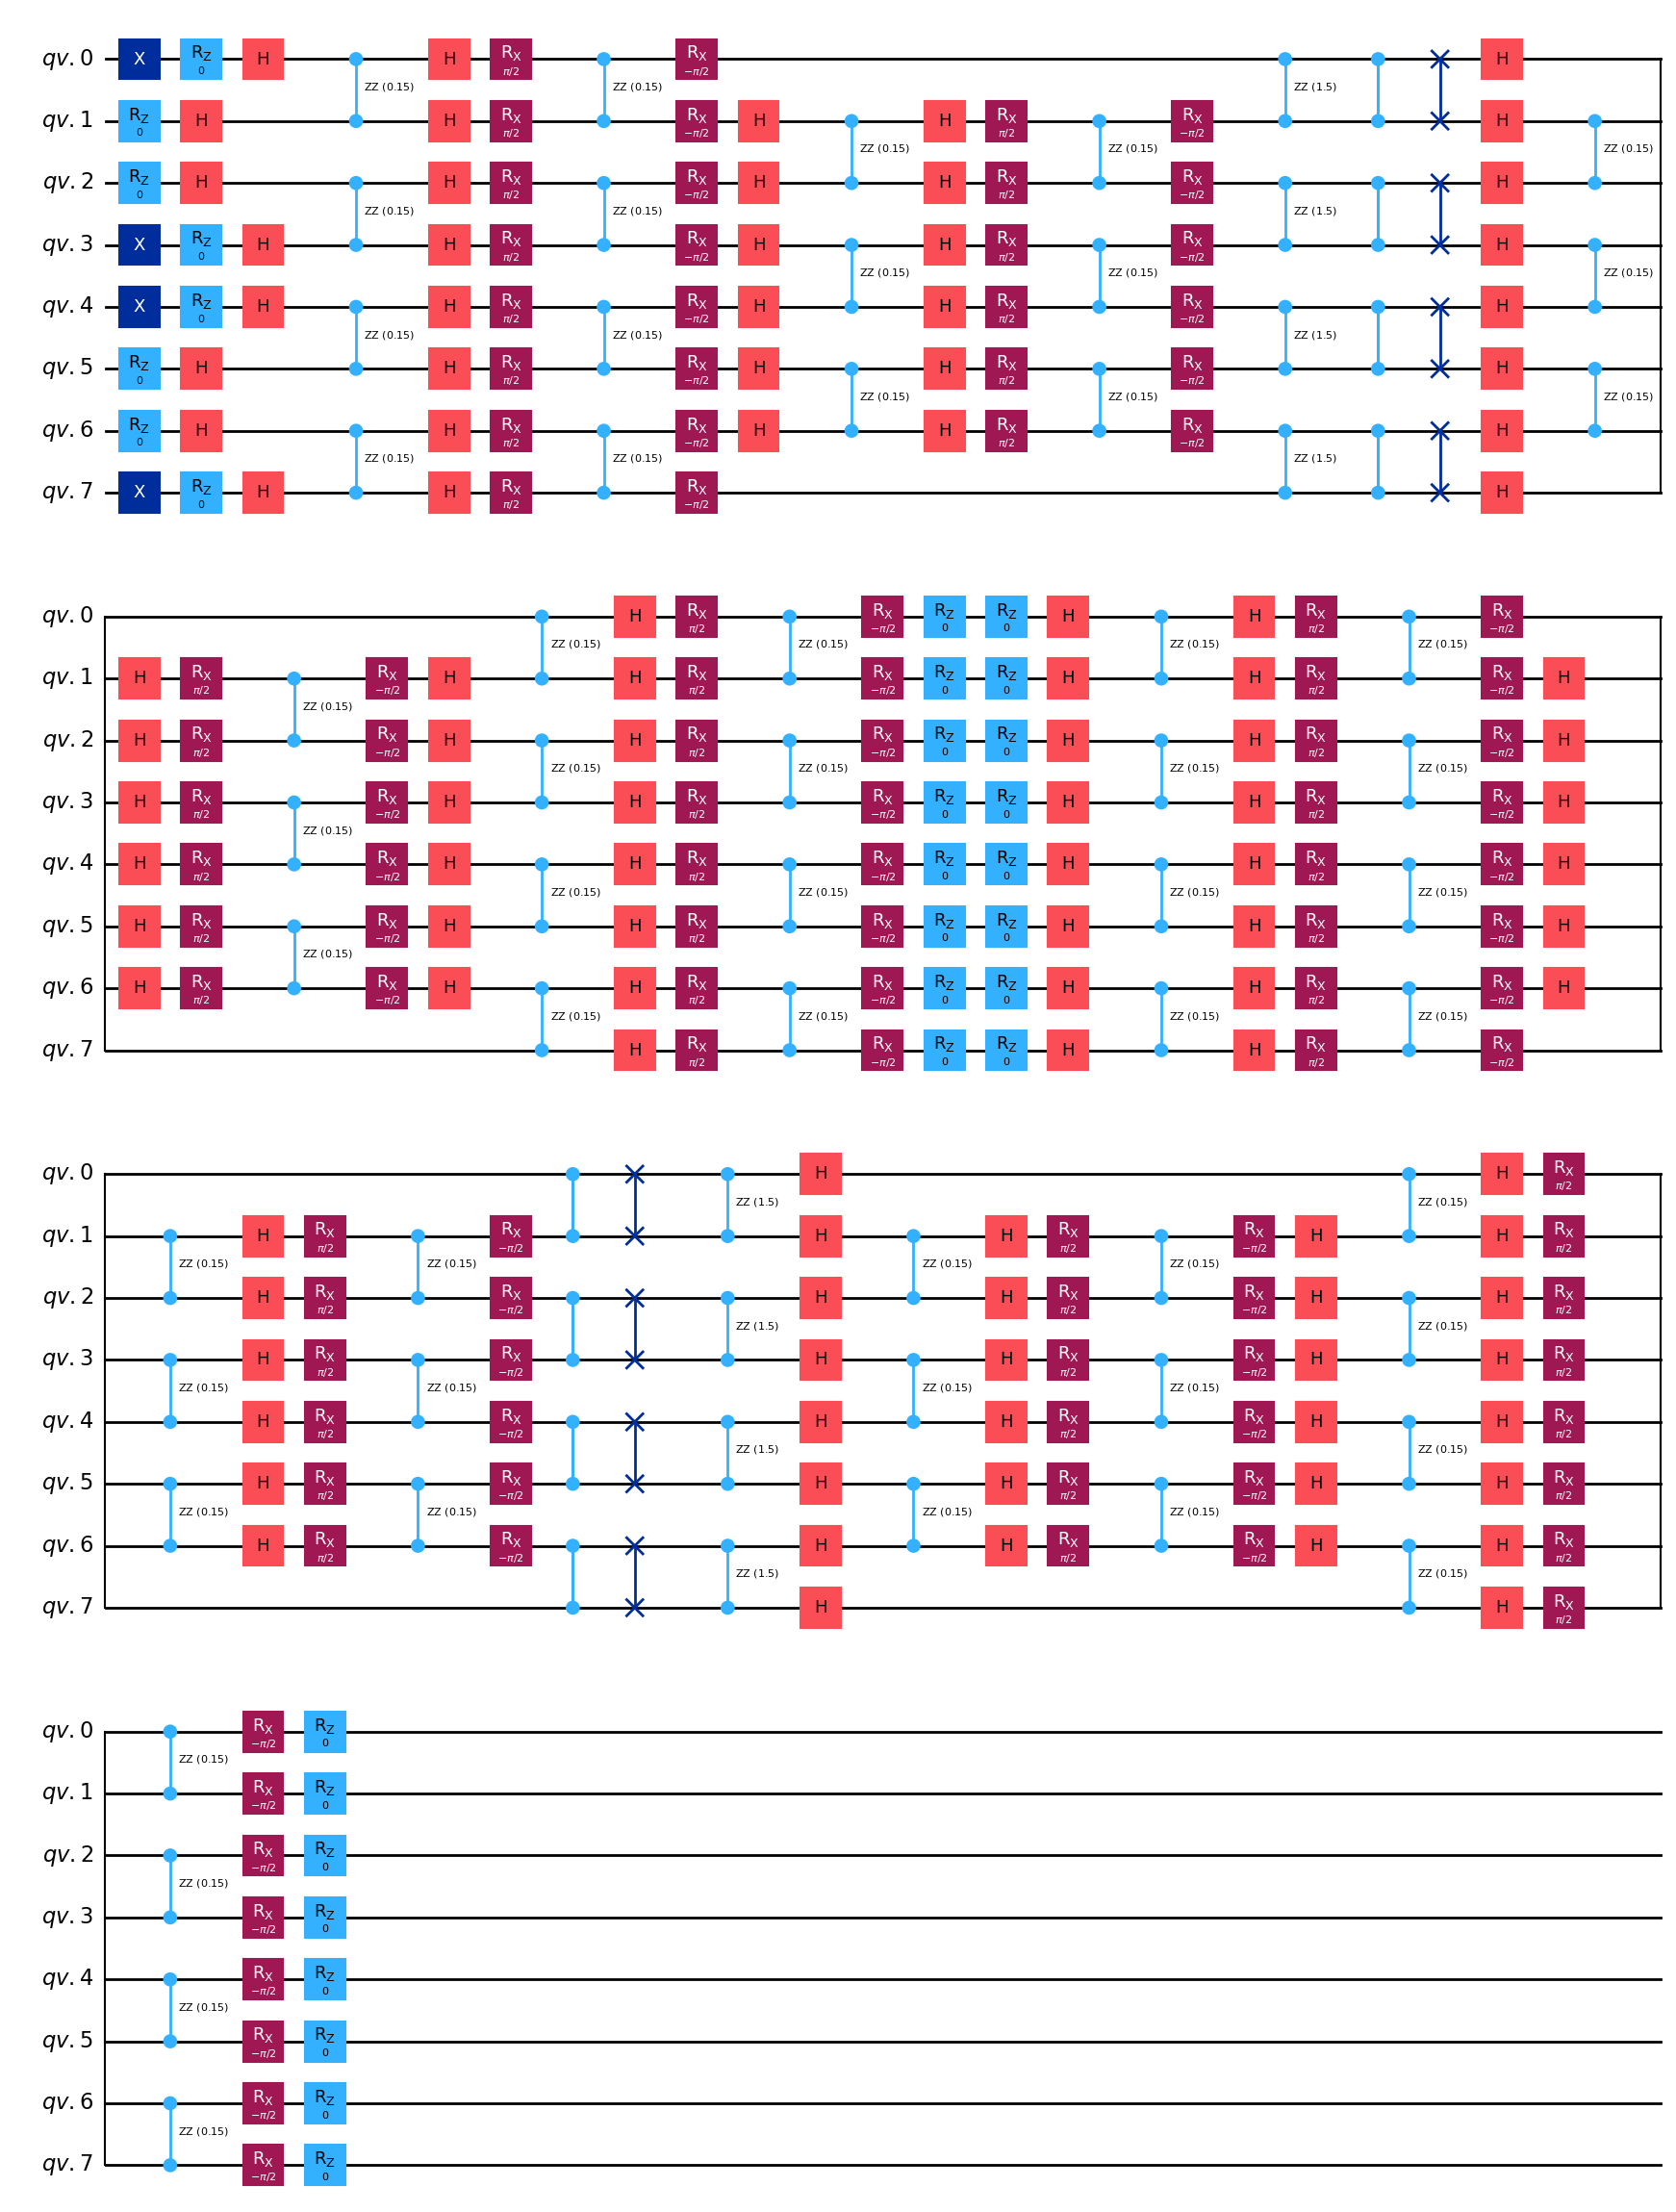

In [43]:
qt = qc.qs.to_qiskit()


circuit_drawer(qt, output="mpl")
